In [29]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [30]:
load_dotenv() 
llm = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0.2)

In [31]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [32]:
def create_joke(state: JokeState):
    prompt =f'Generate a joke on the topic {state["topic"]}'
    joke = llm.invoke(prompt).content
    return {'joke': joke}

In [33]:
def explain_joke(state: JokeState):
    prompt = f'Write the details explanation of the joke {state["joke"]}'
    explanation = llm.invoke(prompt).content
    return {'explanation': explanation}

In [34]:
check_pointer = InMemorySaver()
graph = StateGraph(JokeState)

graph.add_node('create_joke', create_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'create_joke')
graph.add_edge('create_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

workflow =graph.compile(checkpointer=check_pointer)

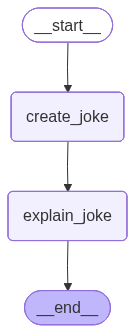

In [35]:
workflow

In [39]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "chicken"}, config=config1)

{'topic': 'chicken',
 'joke': 'Why did the chicken join a band?  \n\nBecause it had the drumsticks and wanted to *cluck* up a rhythm!',
 'explanation': '**Why did the chicken join a band?  \nBecause it had the drumsticks and wanted to *cluck* up a rhythm!**\n\n---\n\n### 1. The classic “Why did the chicken…” set‑up\n\nThe joke starts with the familiar “Why did the chicken…?” format that most people recognize from the classic “Why did the chicken cross the road?” punchline. That immediately signals to the listener that we’re about to hear a light‑hearted, animal‑centric twist on a well‑known joke structure.\n\n### 2. Two layers of “drumsticks”\n\n- **Literal meaning** – A chicken’s legs are often called “drumsticks” in everyday speech.  \n- **Musical meaning** – Drumsticks are the sticks a drummer uses to hit a drum kit.\n\nBy saying the chicken “had the drumsticks,” the joke plays on the double meaning. It’s a clever way to say the chicken already possessed the *instrument* it would ne

In [37]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'tea', 'joke': 'Why did the tea bag go to therapy?  \nBecause it was tired of being left to steep in its own past!', 'explanation': '**Why did the tea bag go to therapy?  \nBecause it was tired of being left to steep in its own past!**\n\n---\n\n### 1. The structure of the joke\n\n| Part | What it does | Why it works |\n|------|--------------|--------------|\n| **Question** | “Why did the tea bag go to therapy?” | Sets up a classic “Why did X do Y?” format that invites a punchline. |\n| **Answer** | “Because it was tired of being left to steep in its own past!” | Delivers a pun‑laden, absurd explanation that subverts the expectation that a tea bag is a simple inanimate object. |\n\n---\n\n### 2. The key wordplay\n\n| Word | Literal meaning | Figurative / double meaning | How it’s used in the joke |\n|------|-----------------|-----------------------------|---------------------------|\n| **Tea bag** | A small pouch of dried tea leaves | Personified “charact

In [43]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'chicken', 'joke': 'Why did the chicken join a band?  \n\nBecause it had the drumsticks and wanted to *cluck* up a rhythm!', 'explanation': '**Why did the chicken join a band?  \nBecause it had the drumsticks and wanted to *cluck* up a rhythm!**\n\n---\n\n### 1. The classic “Why did the chicken…” set‑up\n\nThe joke starts with the familiar “Why did the chicken…?” format that most people recognize from the classic “Why did the chicken cross the road?” punchline. That immediately signals to the listener that we’re about to hear a light‑hearted, animal‑centric twist on a well‑known joke structure.\n\n### 2. Two layers of “drumsticks”\n\n- **Literal meaning** – A chicken’s legs are often called “drumsticks” in everyday speech.  \n- **Musical meaning** – Drumsticks are the sticks a drummer uses to hit a drum kit.\n\nBy saying the chicken “had the drumsticks,” the joke plays on the double meaning. It’s a clever way to say the chicken already possessed the *ins

In [45]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'coffee'}, config=config2)

{'topic': 'coffee',
 'joke': 'Why did the coffee file a police report?  \nBecause it got mugged every morning! ☕️😂',
 'explanation': '**Why did the coffee file a police report?  \nBecause it got mugged every morning! ☕️😂**\n\n---\n\n### 1. The Structure of the Joke\n\n| Element | What it is | Why it matters |\n|---------|------------|----------------|\n| **Setup** | “Why did the coffee file a police report?” | A classic “Why did X do Y?” format that primes the listener for a punchline. |\n| **Punchline** | “Because it got mugged every morning!” | The twist that delivers the double‑meaning. |\n| **Emojis** | ☕️ (coffee cup) + 😂 (laughing face) | Visual cues that reinforce the coffee theme and signal humor. |\n\nThe joke follows a *question‑answer* pattern that is common in short, one‑liner jokes. The humor comes from the surprise in the answer, which hinges on a play on words.\n\n---\n\n### 2. The Core Wordplay: “Mugged”\n\n| Interpretation | How it’s used in the joke | Why it’s funny |

In [46]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'chicken', 'joke': 'Why did the chicken join a band?  \n\nBecause it had the drumsticks and wanted to *cluck* up a rhythm!', 'explanation': '**Why did the chicken join a band?  \nBecause it had the drumsticks and wanted to *cluck* up a rhythm!**\n\n---\n\n### 1. The classic “Why did the chicken…” set‑up\n\nThe joke starts with the familiar “Why did the chicken…?” format that most people recognize from the classic “Why did the chicken cross the road?” punchline. That immediately signals to the listener that we’re about to hear a light‑hearted, animal‑centric twist on a well‑known joke structure.\n\n### 2. Two layers of “drumsticks”\n\n- **Literal meaning** – A chicken’s legs are often called “drumsticks” in everyday speech.  \n- **Musical meaning** – Drumsticks are the sticks a drummer uses to hit a drum kit.\n\nBy saying the chicken “had the drumsticks,” the joke plays on the double meaning. It’s a clever way to say the chicken already possessed the *inst

In [47]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'chicken', 'joke': 'Why did the chicken join a band?  \n\nBecause it had the drumsticks and wanted to *cluck* up a rhythm!', 'explanation': '**Why did the chicken join a band?  \nBecause it had the drumsticks and wanted to *cluck* up a rhythm!**\n\n---\n\n### 1. The classic “Why did the chicken…” set‑up\n\nThe joke starts with the familiar “Why did the chicken…?” format that most people recognize from the classic “Why did the chicken cross the road?” punchline. That immediately signals to the listener that we’re about to hear a light‑hearted, animal‑centric twist on a well‑known joke structure.\n\n### 2. Two layers of “drumsticks”\n\n- **Literal meaning** – A chicken’s legs are often called “drumsticks” in everyday speech.  \n- **Musical meaning** – Drumsticks are the sticks a drummer uses to hit a drum kit.\n\nBy saying the chicken “had the drumsticks,” the joke plays on the double meaning. It’s a clever way to say the chicken already possessed the *ins

In [48]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'coffee', 'joke': 'Why did the coffee file a police report?  \nBecause it got mugged every morning! ☕️😂', 'explanation': '**Why did the coffee file a police report?  \nBecause it got mugged every morning! ☕️😂**\n\n---\n\n### 1. The Structure of the Joke\n\n| Element | What it is | Why it matters |\n|---------|------------|----------------|\n| **Setup** | “Why did the coffee file a police report?” | A classic “Why did X do Y?” format that primes the listener for a punchline. |\n| **Punchline** | “Because it got mugged every morning!” | The twist that delivers the double‑meaning. |\n| **Emojis** | ☕️ (coffee cup) + 😂 (laughing face) | Visual cues that reinforce the coffee theme and signal humor. |\n\nThe joke follows a *question‑answer* pattern that is common in short, one‑liner jokes. The humor comes from the surprise in the answer, which hinges on a play on words.\n\n---\n\n### 2. The Core Wordplay: “Mugged”\n\n| Interpretation | How it’s used in the jok